##**Contexto**

O mercado brasileiro de meios de pagamento movimentou R$ 4,7 trilhões em transações com cartão em 2023, com perdas bilionárias anuais por fraude. Em carteiras reais, fraudes representam menos de 0,2% das transações — modelos treinados nesse cenário tendem a aprender que "aprovar tudo" minimiza o erro, chegando a 99,8% de acurácia sem detectar uma fraude sequer. Métricas convencionais (accuracy, ROC-AUC) mascaram esse comportamento. Além disso, a maioria dos projetos comete o erro de usar split aleatório entre treino e teste, permitindo que o modelo "veja o futuro" — em produção isso superestima a performance real

##**Objetivo**

Desenvolver um sistema de detecção de fraude em duas etapas (two-stage) com foco em aplicabilidade real. O Stage 1 usa Isolation Forest treinado apenas em transações legítimas para pontuar anomalias sem depender de exemplos de fraude rotulados (escassos e enviesados). Apenas as transações mais suspeitas avançam ao Stage 2, reduzindo o volume em até 90% e aumentando a proporção de fraudes no subconjunto. O Stage 2 aplica um classificador LightGBM otimizado via Optuna sobre esse subconjunto filtrado, em cenário de desbalanceamento muito menos severo. O threshold de decisão é determinado pela minimização do custo total de negócio (fraude não detectada vs. bloqueio indevido), não fixado em 0,5. A avaliação usa split temporal, replicando condições reais de implantação.

## **Estrutura do dataset**

### **Time**

Segundos decorridos entre cada transação e a primeira transação do dataset. Como o dataset cobre ~48 horas, o valor vai de 0 até ~172.792. É a coluna que permite fazer o split temporal que você já definiu no projeto.

### **V1 a V28**

As 28 componentes principais geradas via PCA sobre as features originais (que são confidenciais). Por isso não têm interpretação direta de negócio — você não sabe o que cada uma representa. O que se sabe é que o PCA já capturou a maior parte da variância dos dados originais nessas 28 dimensões. Algumas dessas componentes têm alta separabilidade entre fraude e legítima (especialmente V14, V17, V12), o que vai aparecer na EDA e no SHAP.

### **Amount**

O valor monetário da transação em euros. É a única feature com interpretação direta de negócio além de Time. Tem distribuição muito assimétrica (maioria das transações é de valores baixos, com alguns outliers altos) — daí a escolha do RobustScaler em vez do StandardScaler. Também é central no notebook 05, já que o custo de uma fraude não detectada depende diretamente do Amount.

### **Class**

A variável-alvo binária:

0 → transação legítima (284.315 casos, 99,83%)
1 → fraude (492 casos, 0,17%)

## **EDA**



### Etapa 1: Inspeção Inicial e Limpeza dos Dados

In [ ]:
import pandas as pd

df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo visual padrão para todos os gráficos do projeto
sns.set_theme(style="whitegrid", palette="muted")

# ----------------------------------------------------------------
# 1. VISÃO GERAL DO DATASET
# ----------------------------------------------------------------

print("=" * 55)
print("SHAPE DO DATASET")
print("=" * 55)
print(f"Linhas    : {df.shape[0]:,}")
print(f"Colunas   : {df.shape[1]}")

print("\n" + "=" * 55)
print("TIPOS DE DADOS")
print("=" * 55)
print(df.dtypes)

SHAPE DO DATASET
Linhas    : 284,807
Colunas   : 31

TIPOS DE DADOS
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [ ]:
# ----------------------------------------------------------------
# 2. VALORES AUSENTES
# ----------------------------------------------------------------
# Em dados de transação, NaN pode significar falha de captura
# no sistema de pagamento isso precisa ser identificado antes
# de qualquer modelagem.

ausentes = df.isnull().sum()
pct_ausentes = (ausentes / len(df)) * 100

resumo_ausentes = pd.DataFrame({
    "qtd_nulos": ausentes,
    "pct_nulos": pct_ausentes
}).query("qtd_nulos > 0")  # mostra só quem tem problema

if resumo_ausentes.empty:
    print("Nenhum valor ausente encontrado.")
else:
    print(resumo_ausentes)

Nenhum valor ausente encontrado.


In [ ]:
# ----------------------------------------------------------------
# 3. DUPLICATAS
# ----------------------------------------------------------------
# Duplicatas em dados de transação são críticas:
# podem inflar artificialmente o recall do modelo se
# a mesma transação aparecer em treino e teste.

n_duplicatas = df.duplicated().sum()
print(f"Transações duplicadas: {n_duplicatas}")

if n_duplicatas > 0:
    # Remove e registra quantas foram removidas
    df = df.drop_duplicates()
    print(f"Removidas. Novo shape: {df.shape}")

Transações duplicadas: 1081
Removidas. Novo shape: (283726, 31)


In [ ]:
# ----------------------------------------------------------------
# 4. TIPOS DAS COLUNAS — CONSISTÊNCIA
# ----------------------------------------------------------------
# Todas as colunas devem ser numéricas (float64).
# Class deve ser int. Qualquer string aqui é sinal de problema.

colunas_erradas = df.select_dtypes(exclude=["number"]).columns.tolist()

if colunas_erradas:
    print(f"Colunas com tipo inesperado: {colunas_erradas}")
else:
    print("Todos os tipos estão corretos — apenas numéricos.")

# Garante que Class é inteiro (0 ou 1)
df["Class"] = df["Class"].astype(int)

Todos os tipos estão corretos — apenas numéricos.


In [ ]:
# ----------------------------------------------------------------
# 5. VALORES NEGATIVOS EM AMOUNT
# ----------------------------------------------------------------
# Amount representa valor de transação e nunca deve ser negativo.
# Se houver, é dado corrompido ou erro de sistema.

negativos = (df["Amount"] < 0).sum()
print(f"Transações com Amount negativo: {negativos}")

# Time também não pode ser negativo
negativos_time = (df["Time"] < 0).sum()
print(f"Transações com Time negativo: {negativos_time}")

Transações com Amount negativo: 0
Transações com Time negativo: 0


In [ ]:
# ----------------------------------------------------------------
# 6. ESTATÍSTICAS DESCRITIVAS POR CLASSE
# ----------------------------------------------------------------
# Ver separadamente fraude vs legítima já revela
# padrões de comportamento antes de qualquer modelo.

print("LEGÍTIMAS (Class = 0)")
print(df[df["Class"] == 0][["Time", "Amount"]].describe().round(2))

print("\nFRAUDES (Class = 1)")
print(df[df["Class"] == 1][["Time", "Amount"]].describe().round(2))

LEGÍTIMAS (Class = 0)
            Time     Amount
count  283253.00  283253.00
mean    94835.06      88.41
std     47475.55     250.38
min         0.00       0.00
25%     54233.00       5.67
50%     84711.00      22.00
75%    139308.00      77.46
max    172792.00   25691.16

FRAUDES (Class = 1)
            Time   Amount
count     473.00   473.00
mean    80450.51   123.87
std     48636.18   260.21
min       406.00     0.00
25%     41203.00     1.00
50%     73408.00     9.82
75%    129095.00   105.89
max    170348.00  2125.87


###**Duplicatas é um ponto de atenção relevante**

Saímos de 284.807 para 283.726 linhas, e o número de fraudes caiu de 492 para 473, ou seja, 19 das duplicatas removidas eram fraudes. Isso importa porque se não fosse feito essa limpeza, o mesmo registro de fraude poderia aparecer em treino e teste simultaneamente, inflando o recall artificialmente. Em produção isso se chama data leakage e é um dos erros mais comuns que vejo em projetos.


### **Observações da análise descritiva:**

**Fraude**: Amount médio de 123 vs legítima 88 - Fraudadores não necessariamente fazem compras pequenas

**Fraude**: Amount p25 = 1,00 vs legítima 5,67 - Muitas fraudes de valor baixo podendo ser um padrão de "teste de cartão"

**Fraude**: Amount máx = 2.125 vs legítima 25.691 - Fraudes raramente chegam em valores altíssimos pde ser um limite de autorização ou cautela do fraudador

**Fraude**: Time médio menor (80k vs 94k segundos) - Fraudes ligeiramente concentradas no primeiro dia precisa confirmar isso na análise temporal

Distribuição de classes:
          qtd  pct (%)
Class                 
0      283253   99.833
1         473    0.167


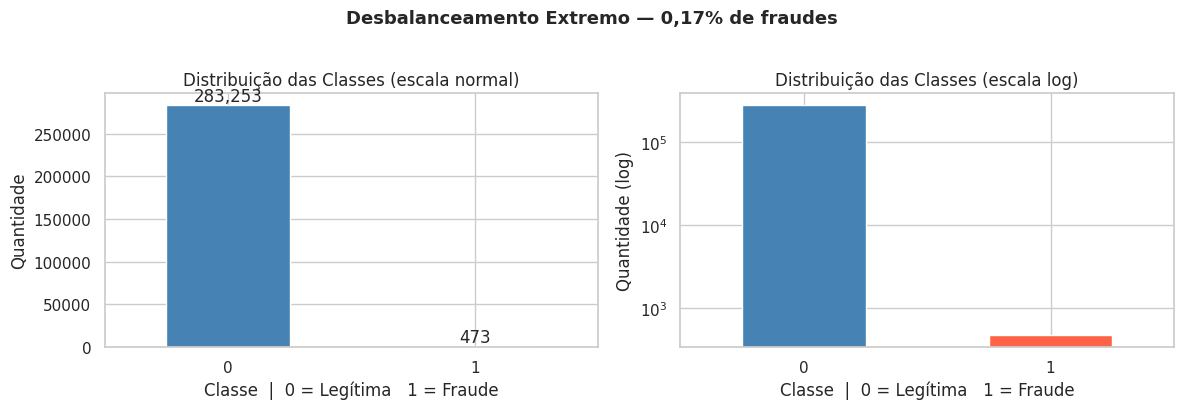

In [ ]:
# ----------------------------------------------------------------
# 7. DISTRIBUIÇÃO DA VARIÁVEL TARGET
# ----------------------------------------------------------------

contagem = df["Class"].value_counts()
pct = df["Class"].value_counts(normalize=True) * 100

print("Distribuição de classes:")
print(pd.DataFrame({"qtd": contagem, "pct (%)": pct.round(3)}))

# Gráfico de barras com escala log (sem log, a fraude some visualmente)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Escala normal — mostra o problema visualmente
contagem.plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"],
              edgecolor="white", rot=0)
axes[0].set_title("Distribuição das Classes (escala normal)")
axes[0].set_xlabel("Classe  |  0 = Legítima   1 = Fraude")
axes[0].set_ylabel("Quantidade")
axes[0].bar_label(axes[0].containers[0], fmt="{:,.0f}")

# Escala log — permite visualizar a fraude sem sumir
contagem.plot(kind="bar", ax=axes[1], color=["steelblue", "tomato"],
              edgecolor="white", rot=0, logy=True)
axes[1].set_title("Distribuição das Classes (escala log)")
axes[1].set_xlabel("Classe  |  0 = Legítima   1 = Fraude")
axes[1].set_ylabel("Quantidade (log)")

plt.suptitle("Desbalanceamento Extremo — 0,17% de fraudes",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Etapa 2: Análise Temporal e Distribuição das Features

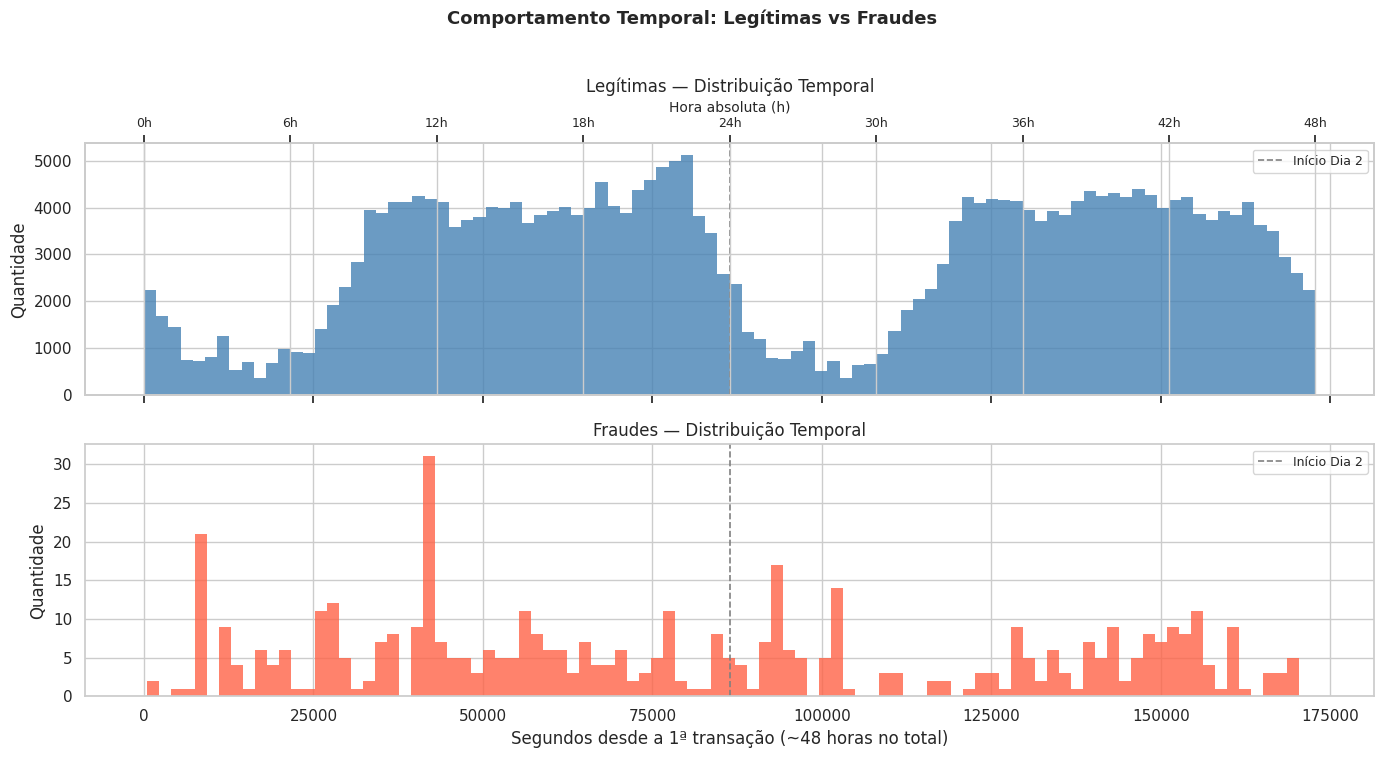

In [ ]:
# ----------------------------------------------------------------
# 1. ANÁLISE TEMPORAL — com eixo superior em horas
# ----------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Legítimas
axes[0].hist(df[df["Class"] == 0]["Time"], bins=96,
             color="steelblue", alpha=0.8, edgecolor="none")
axes[0].set_title("Legítimas — Distribuição Temporal")
axes[0].set_ylabel("Quantidade")

# Fraudes
axes[1].hist(df[df["Class"] == 1]["Time"], bins=96,
             color="tomato", alpha=0.8, edgecolor="none")
axes[1].set_title("Fraudes — Distribuição Temporal")
axes[1].set_ylabel("Quantidade")
axes[1].set_xlabel("Segundos desde a 1ª transação (~48 horas no total)")

plt.suptitle("Comportamento Temporal: Legítimas vs Fraudes",
             fontsize=13, fontweight="bold", y=1.08)
plt.tight_layout()

# ----------------------------------------------------------------
# Eixo superior em horas — adicionado no subplot de cima
# ----------------------------------------------------------------
# Pega os ticks do eixo X principal e converte para horas
ax_horas = axes[0].twiny()

# Limites idênticos ao eixo original (em segundos)
ax_horas.set_xlim(axes[0].get_xlim())

# Define os ticks a cada 6 horas (6h * 3600s = 21600s)
ticks_segundos = np.arange(0, 172800 + 1, 21600)
ticks_horas    = (ticks_segundos / 3600).astype(int)

ax_horas.set_xticks(ticks_segundos)
ax_horas.set_xticklabels([f"{h}h" for h in ticks_horas],
                          fontsize=9)
ax_horas.set_xlabel("Hora absoluta (h)", fontsize=10)

# Linhas verticais de referência a cada 24h (início de cada dia)
for ax in axes:
    ax.axvline(86400, color="gray", linestyle="--",
               linewidth=1.2, label="Início Dia 2")
    ax.legend(fontsize=9)

plt.show()

**Legítimas (azul) — padrão circadiano claro**

É possível ver dois vales profundos, um por volta de 25.000s e outro em ~115.000s. Esses são os dois períodos de madrugada do dataset (que cobre ~48h). O volume sobe durante o dia e cai à noite. Comportamento exatamente esperado para transações legítimas e as pessoas costumam comprar mais durante o dia.

**Fraudes (vermelho) — padrão completamente diferente**

Distribuição muito mais irregular, sem o ritmo circadiano das legítimas. Os picos são aleatórios e o volume não cai nas madrugadas na mesma proporção. Isso é um sinal clássico de comportamento fraudulento, bots e fraudadores não dormem, e muitas operações são feitas justamente quando o monitoramento humano é menor.

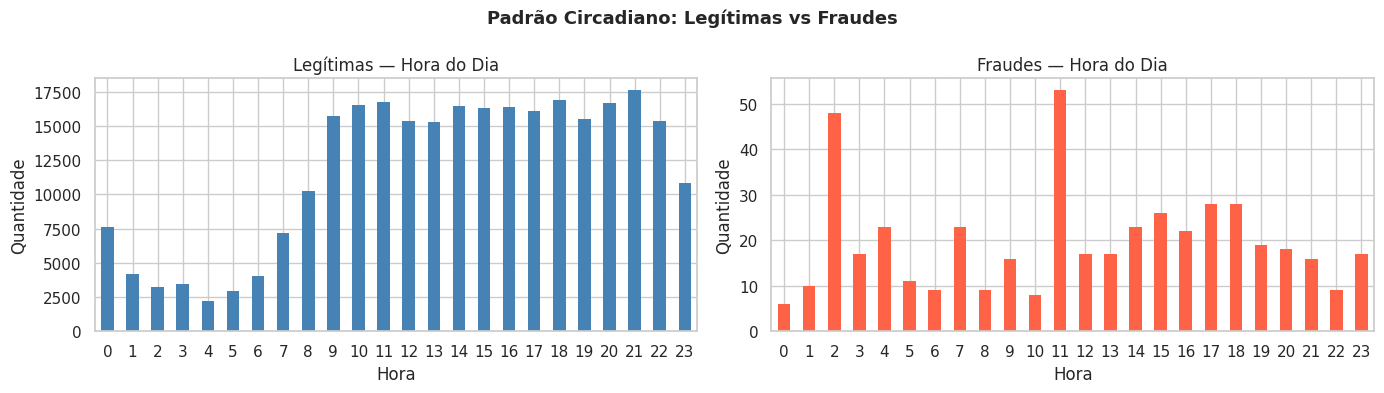

In [ ]:
# ----------------------------------------------------------------
# 2. VOLUME DE TRANSAÇÕES POR HORA DO DIA (ciclo de 24h)
# ----------------------------------------------------------------
# Aqui usei hora do dia real (0–23), não a hora absoluta.
# Isso revela o padrão circadiano — essencial para justificar
# o encoding cíclico seno/cosseno que faremos nas etapas posteriores

df["Hour_of_day"] = (df["Time"] / 3600 % 24).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Legítimas por hora do dia
df[df["Class"] == 0].groupby("Hour_of_day").size().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="none"
)
axes[0].set_title("Legítimas — Hora do Dia")
axes[0].set_xlabel("Hora")
axes[0].set_ylabel("Quantidade")
axes[0].tick_params(axis="x", rotation=0)

# Fraudes por hora do dia
df[df["Class"] == 1].groupby("Hour_of_day").size().plot(
    kind="bar", ax=axes[1], color="tomato", edgecolor="none"
)
axes[1].set_title("Fraudes — Hora do Dia")
axes[1].set_xlabel("Hora")
axes[1].set_ylabel("Quantidade")
axes[1].tick_params(axis="x", rotation=0)

plt.suptitle("Padrão Circadiano: Legítimas vs Fraudes",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Legítimas (azul) — ritmo humano claro**

Volume despenca das 3h às 6h da manhã é a madrugada real. Sobe progressivamente a partir das 7h, atinge o pico entre 10h e 22h e cai à meia-noite. Comportamento 100% esperado para consumidores reais.

**Fraudes (vermelho) — comportamento anômalo confirmado**

Dois picos altíssimos: 2h da manhã (~ 48 transações) e 11h (~ 56 transações). O volume na madrugada mal cai comparado às legítimas enquanto isso as legítimas somem entre 3h e 6h, as fraudes continuam ativas. Isso é padrão clássico de ataque automatizado podendo ser bots porque operam quando o monitoramento humano é baizo.

**O que isso importante para o projeto:**

Fraudes ativas na madrugada (2h–4h) Hour vai ser feature discriminativa no Stage 2

Pico de fraude às 11h também e não é só madrugada há padrão de horário comercial também

Legítimas somem entre 3h–6h e a diferença nesse intervalo é o sinal mais forte porque dois picos distintos de fraude sugere possivelmente dois perfis de fraude diferentes

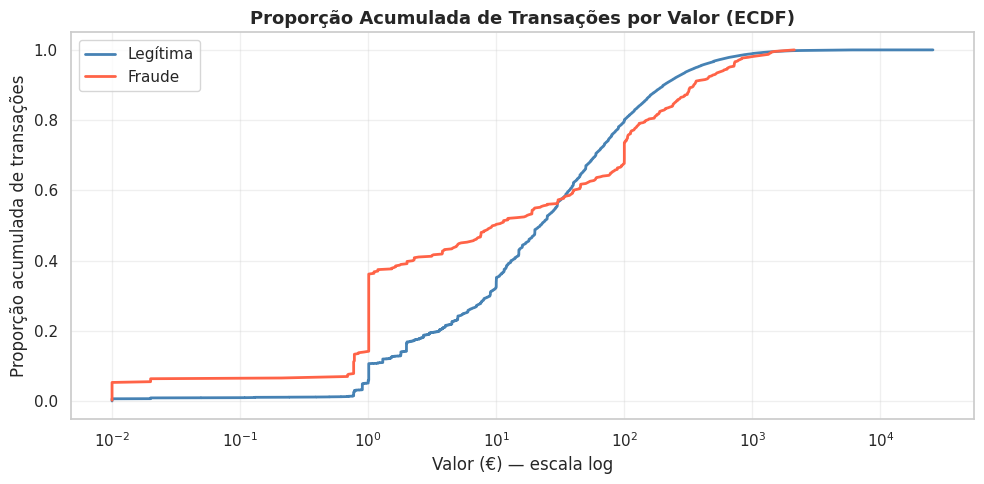

In [ ]:
# ----------------------------------------------------------------
# 3. DISTRIBUIÇÃO DE AMOUNT POR CLASSE — ECDF
# ----------------------------------------------------------------
# ECDF mostra a proporção acumulada de transações até cada valor.
# Não depende de bins e lida bem com concentração extrema
# em valores baixos — muito mais claro que histograma aqui.

fig, ax = plt.subplots(figsize=(10, 5))

for classe, cor, label in [(0, "steelblue", "Legítima"),
                            (1, "tomato", "Fraude")]:
    valores = np.sort(df[df["Class"] == classe]["Amount"] + 0.01)
    proporcao_acumulada = np.arange(1, len(valores) + 1) / len(valores)
    ax.plot(valores, proporcao_acumulada, color=cor,
            label=label, linewidth=2)

ax.set_xscale("log")
ax.set_title("Proporção Acumulada de Transações por Valor (ECDF)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Valor (€) — escala log")
ax.set_ylabel("Proporção acumulada de transações")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

O salto abrupto da curva vermelha em ~€1 é o dado mais importante aqui porque ela pula quase instantaneamente em torno de €1,00. Isso confirma de forma muito mais nítida um padrão de testagem do cartão, uma proporção enorme das fraudes está concentrada bem próxima de €1, exatamente o comportamento esperado de um fraudador testando se o cartão está ativo antes de fazer uma compra maior.
Cruzamento das curvas por volta de ~€30–€50: até esse ponto, a proporção acumulada de fraude é maior que a de legítima (fraude concentrada em valores baixos). Depois desse ponto elas se aproximam e a legítima ultrapassa isso pode representar o reflexo de compras legítimas de ticket médio/alto sendo mais comuns que fraudes de valor alto (bate com o Amount máximo de fraude ser €2.125 vs €25.691 da legítima, que vimos na etapa 1).
Cauda longa muito mais curta na fraude, a curva vermelha atinge 1,0 bem antes da azul, fraude praticamente não acontece em valores muito altos, enquanto a legítima ainda tem transações relevantes até a casa dos milhares.

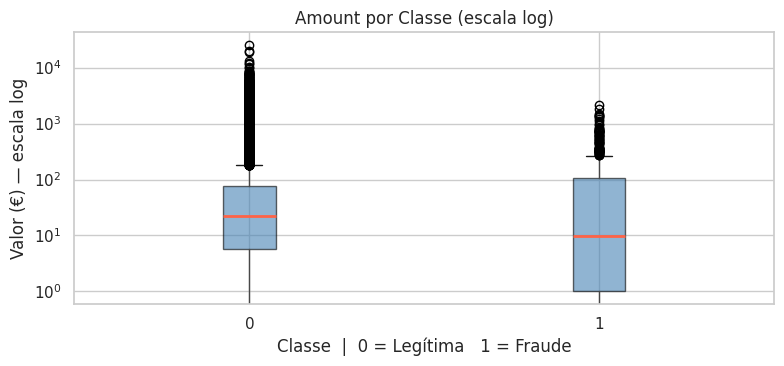

In [ ]:
# ----------------------------------------------------------------
# Complemento: Boxplot de Amount por classe (escala log)
# ----------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 4))

df.boxplot(column="Amount", by="Class", ax=ax,
           patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.6),
           medianprops=dict(color="tomato", linewidth=2))

ax.set_yscale("log")
ax.set_title("Amount por Classe (escala log)")
ax.set_xlabel("Classe  |  0 = Legítima   1 = Fraude")
ax.set_ylabel("Valor (€) — escala log")
plt.suptitle("")  # remove título automático duplicado do pandas
plt.tight_layout()
plt.show()

1. Mediana da fraude é menor que a legítima
€9,82 vs €22,00 que confirma visualmente o padrão de testagem de cartão que o ECDF já mostrou, metade das fraudes está em valores baixos, testando o cartão antes de um golpe maior.

2. O box da fraude é proporcionalmente mais largo (maior IQR relativo)
Vai de ~€1 a ~€105, uma amplitude de duas ordens de grandeza dentro do próprio box. A legítima vai de ~€5,67 a ~€77,46 demonstrando ser menos dispersa relativamente. Isso sugere que fraude não é um comportamento único: existe o grupo de "teste de cartão" (valores baixos) e o grupo que já tenta o golpe de valor mais alto assim que confirma que o cartão funciona, daí o Q3 da fraude ser até maior que o da legítima.

3. A legítima tem uma nuvem densa de outlier. A fraude tem poucos outliers e o teto deles é muito mais baixo. Isso reforça algo que já vimos, que fraudadores evitam valores muito altos, provavelmente por dois motivos prováveis: sistemas antifraude tradicionais (baseados em regra) já bloqueiam valores muito altos, e/ou o próprio fraudador quer passar despercebido, evitando levantar suspeita com uma transação atípica.

4. Os whiskers se sobrepõem parcialmente e não há separação limpa entre as duas classes, há uma zona de sobreposição considerável (aproximadamente €5 a €100), onde uma transação legítima e uma fraudulenta podem ter valores parecidos. Isso é o ponto mais importante do gráfico: Amount sozinho não é suficiente para separar as classes, é um sinal complementar, não decisivo. Reforça por que o projeto usa 30 features (V1–V28 + Amount + Hour) e uma arquitetura two-stage, em vez de depender de uma regra simples tipo "bloquear valores baixos".

**Amount está validado como feature forte:**

Salto abrupto perto de €1 - Amount será feature de alto poder discriminativo

Cruzamento em €30–€50, não é uma relação linear simples reforçando a escolha de modelos não-lineares (LightGBM, Isolation Forest)

Cauda curta da fraude justifica o RobustScaler — a diferença de escala entre as classes não deve ser tratada como "outlier a remover", é sinal real

Top 10 features mais discriminativas (effect size):
Feature  Effect_Size
    V17     7.684501
    V14     7.191247
    V12     6.145458
    V10     5.073300
    V16     4.588323
     V3     4.469101
     V7     4.224576
    V11     3.653948
     V4     3.170048
    V18     2.582098


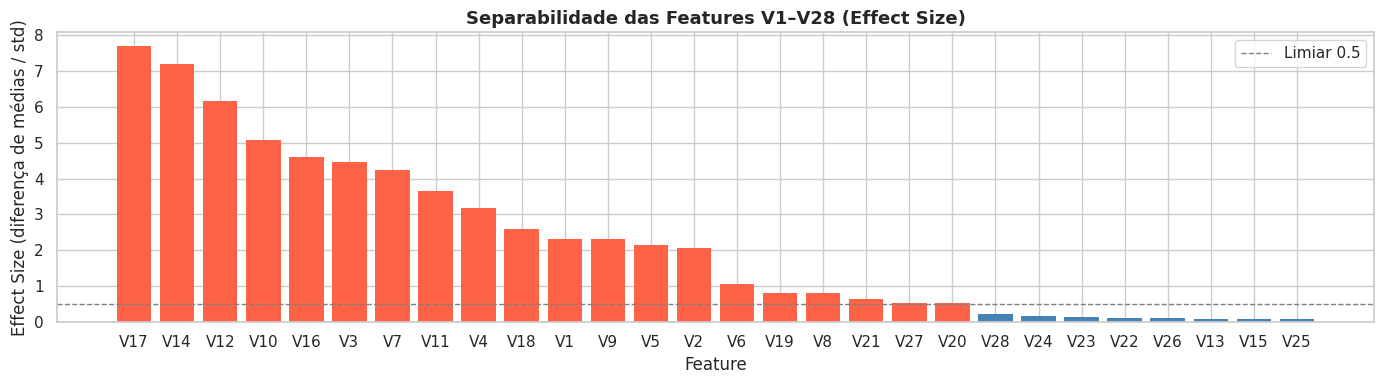

In [ ]:
# ----------------------------------------------------------------
# 4. SEPARABILIDADE DAS FEATURES V1–V28
# ----------------------------------------------------------------
# Sem poder interpretar o significado das componentes PCA,
# a métrica mais útil é: qual feature separa melhor fraude
# de legítima? Usamos a diferença absoluta de médias
# normalizada pelo desvio padrão (effect size simples).
# Features com maior effect size são as mais discriminativas
# — isso vai bater com o SHAP depois.

v_features = [f"V{i}" for i in range(1, 29)]

effect_sizes = {}
for feat in v_features:
    media_fraude   = df[df["Class"] == 1][feat].mean()
    media_legitima = df[df["Class"] == 0][feat].mean()
    std_total      = df[feat].std()
    effect_sizes[feat] = abs(media_fraude - media_legitima) / std_total

# Ordena do mais ao menos discriminativo
effect_df = (pd.Series(effect_sizes)
               .sort_values(ascending=False)
               .reset_index())
effect_df.columns = ["Feature", "Effect_Size"]

print("Top 10 features mais discriminativas (effect size):")
print(effect_df.head(10).to_string(index=False))

# Gráfico
fig, ax = plt.subplots(figsize=(14, 4))
colors = ["tomato" if e > 0.5 else "steelblue"
          for e in effect_df["Effect_Size"]]
ax.bar(effect_df["Feature"], effect_df["Effect_Size"],
       color=colors, edgecolor="none")
ax.axhline(0.5, color="gray", linestyle="--",
           linewidth=1, label="Limiar 0.5")
ax.set_title("Separabilidade das Features V1–V28 (Effect Size)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Feature")
ax.set_ylabel("Effect Size (diferença de médias / std)")
ax.legend()
plt.tight_layout()
plt.show()

### Análise — Separabilidade das Features V1–V28 (Effect Size)

Para identificar quais componentes PCA carregam maior poder discriminativo entre
fraude e transação legítima, calculamos o **effect size** de cada feature que é basicamente a
diferença absoluta entre as médias das duas classes, normalizada pelo desvio
padrão geral da feature (uma versão simplificada do Cohen's d). Essa métrica
permite comparar as 28 componentes numa escala única, já que elas não têm
interpretação direta de negócio (são combinações lineares de features
confidenciais).

**Resultados:**

- **V17, V14 e V12 lideram o ranking** (effect size de 7,68, 7,19 e 6,15,
  respectivamente), consistente com as informações sobre  tipo de dataset
  costuma reportar.
- **18 das 28 features** ficam acima do limiar de 0,5 (convencionalmente
  considerado "diferença grande" em effect size), com queda abrupta entre
  V18 (2,58) e V6 (1,05).
- As 8 features finais (V28, V24, V23, V22, V26, V13, V15, V25) têm effect
  size próximo de zero, indicando baixa separação linear univariada.

**Observação crítica sobre o dataset:** os valores de effect size encontrados
(alguns acima de 7) são muito superiores ao que se observa tipicamente em
problemas reais de detecção de fraude, onde o sinal costuma estar mais diluído
e ruidoso entre as features. Isso sugere que esse dataset apresenta uma
separabilidade atipicamente alta que é uma característica que o torna didaticamente
útil, mas que deve ser levada em conta ao extrapolar os resultados deste
projeto para um cenário de produção real, onde a performance tende a ser
mais modesta.

**Limitação da métrica:** effect size captura apenas separação linear na
média de cada feature isoladamente. Ele não detecta features que só ganham
poder preditivo em **interação** com outras, nem diferenças de variância
entre classes. Por isso, todas as 30 features (V1–V28 + Amount + Hour) serão
mantidas no pipeline de modelagem e a seleção de importância real será feita
pelo próprio modelo e validada posteriormente via SHAP, que
captura relações não-lineares que essa análise univariada não alcança.

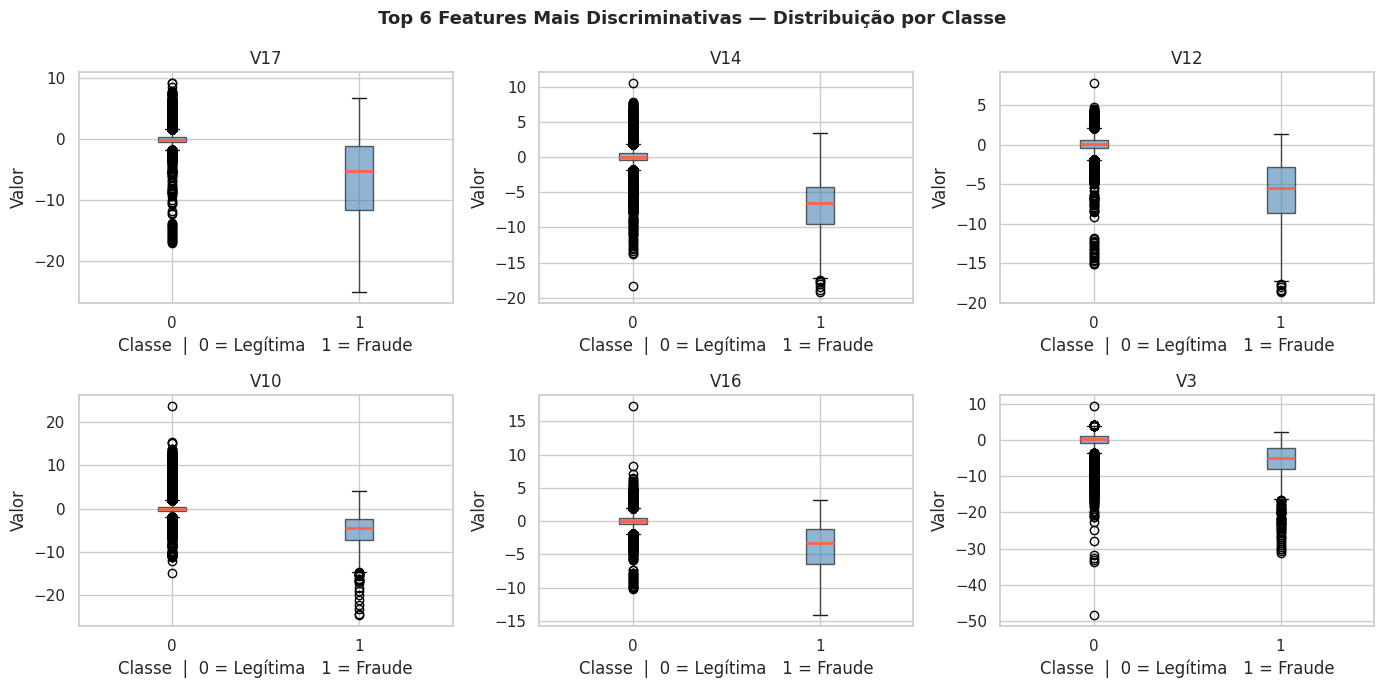

In [ ]:
# ----------------------------------------------------------------
# 5. BOXPLOT DAS TOP 6 FEATURES MAIS DISCRIMINATIVAS
# ----------------------------------------------------------------
# Visualiza a distribuição real de cada feature por classe,
# Isso confirma visualmente o que o effect size sinalizou.

top6 = effect_df.head(6)["Feature"].tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, feat in enumerate(top6):
    df.boxplot(column=feat, by="Class", ax=axes[i],
               patch_artist=True,
               boxprops=dict(facecolor="steelblue", alpha=0.6),
               medianprops=dict(color="tomato", linewidth=2))
    axes[i].set_title(f"{feat}")
    axes[i].set_xlabel("Classe  |  0 = Legítima   1 = Fraude")
    axes[i].set_ylabel("Valor")

plt.suptitle("Top 6 Features Mais Discriminativas — Distribuição por Classe",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Análise — Boxplot das Top 6 Features Mais Discriminativas

Para complementar o ranking de effect size, visualizamos a distribuição das
seis componentes PCA mais discriminativas (V17, V14, V12, V10, V16, V3)
separadas por classe.

**Padrão consistente entre as seis features:**

Em todas elas, a classe legítima concentra-se em um box estreito próximo de
zero, acompanhado de uma cauda longa de outliers o que é um resultado esperado, dado
que o PCA foi ajustado sobre uma base dominada por transações legítimas
(99,8% dos dados). Já a classe fraude apresenta, de forma consistente, um
**deslocamento de mediana para valores negativos**, com boxes mais compactos
e menor quantidade de outliers.

**Observações por feature:**

- **V17, V14 e V12** mostram a separação mais nítida entre as classes,
  coerente com seus effect sizes elevados (7,68 / 7,19 / 6,15).
- **V10** apresenta um cluster de outliers de fraude bem definido entre -15
  e -25, sugerindo possível heterogeneidade dentro do próprio grupo de
  fraudes (indício de mais de um padrão/comportamento fraudulento hipótese que pode ser a explorar em etapas futuras, não aprofundada nesta EDA).
- **V16** mostra separação mais modesta, com maior sobreposição entre os
  boxes consistente com seu effect size intermediário (4,59) frente às
  demais do grupo.
- **V3** opera em escala numérica maior (outliers da legítima chegam a -50),
  mas mantém o mesmo padrão de deslocamento negativo da fraude.

**Interpretação:** o deslocamento consistente para valores negativos em
todas as top 6 features sugere que a fraude captura um padrão de
comportamento sistematicamente diferente do comum mesmo sem conseguir
interpretar o significado de negócio de cada componente PCA. Essa
consistência direcional é um bom sinal de que essas features carregam
sinal real (não ruído), e é esperado que apareçam entre as mais importantes
na análise SHAP do notebook 06.

In [ ]:
# ----------------------------------------------------------------
# SALVANDO O DATASET LIMPO
# ----------------------------------------------------------------
# Formato parquet: mais compacto e rápido que CSV,
# preserva tipos de dados (float64, int64) sem precisar
# reconverter na leitura.

import os

# Garante que a pasta de dados processados existe no Drive
caminho_pasta = "/content/drive/MyDrive/fraud-detection-two-stage/data/processed"
os.makedirs(caminho_pasta, exist_ok=True)

# Remove as colunas auxiliares criadas só para a EDA
# (Hour e Hour_of_day serão recriadas de forma definitiva no feature engineering)
df_limpo = df.drop(columns=["Hour", "Hour_of_day"], errors="ignore")

# Salva o dataset limpo (sem duplicatas, tipos corretos)
caminho_arquivo = f"{caminho_pasta}/creditcard_clean.parquet"
df_limpo.to_parquet(caminho_arquivo, index=False)

print(f"Dataset salvo em: {caminho_arquivo}")
print(f"Shape salvo: {df_limpo.shape}")

Dataset salvo em: /content/drive/MyDrive/fraud-detection-two-stage/data/processed/creditcard_clean.parquet
Shape salvo: (283726, 31)


## **Conclusão Geral — EDA**

Esta análise exploratória teve como objetivo entender a estrutura dos dados
e validar, com evidência empírica, as decisões técnicas definidas para o
pipeline de detecção de fraude em duas etapas. As descobertas abaixo
consolidam essas decisões.

**1. Qualidade e integridade dos dados**

O dataset não apresenta valores ausentes nem valores negativos em `Amount`
ou `Time`. Foram identificadas e removidas **1.081 transações duplicadas**,
das quais **19 eram fraudes** sem essa limpeza, o mesmo registro poderia
aparecer simultaneamente em treino e teste, inflando artificialmente as
métricas de recall (data leakage). Após a limpeza, o dataset final contém
283.726 transações, com 473 fraudes (0,167%).

**2. Split temporal é a escolha correta**

O dataset cobre aproximadamente 48 horas em dois ciclos diários completos,
com padrão circadiano nítido nas transações legítimas (volume despenca
entre 3h–6h da manhã) e comportamento irregular nas fraudes, que se mantêm
ativas mesmo na madrugada. Um split aleatório destruiria essa estrutura
temporal e permitiria que o modelo "veja o futuro" durante o treino,
superestimando a performance real de produção. O split temporal replica
fielmente o cenário de implantação.

**3. Encoding cíclico de Hour é justificado**
A distribuição de fraudes por hora do dia mostra dois picos concentrados
(madrugada, ~2h e ~11h), enquanto legítimas seguem ritmo
humano previsível. Essa natureza cíclica (23h e 0h são contíguas no relógio,
mas numericamente distantes) justifica a transformação seno/cosseno de
`Hour`.

**4. RobustScaler é a escolha correta para Amount**

`Amount` apresenta distribuição extremamente assimétrica, com forte
concentração de fraudes em valores próximos de zero (padrão de *testagem de cartão*, confirmado pela curva ECDF) e outliers legítimos de alto valor
(até ~25.691, contra um teto de fraude de ~2.125). Um StandardScaler seria
distorcido por esses outliers; o RobustScaler, baseado em mediana e IQR,
é robusto a essa assimetria.

**5. Sobreposição entre classes em Amount**

O boxplot revelou sobreposição relevante entre as distribuições de Amount
das duas classes (faixa aproximada de €5 a €100), ou seja, Amount sozinho
não separa fraude de legítima de forma decisiva. É um sinal complementar,
não suficiente isoladamente, o que reforça a necessidade da arquitetura
two-stage com múltiplas features (V1–V28 + Amount + Hour).

**6. Separabilidade das componentes PCA**

Effect size revelou 18 das 28 features V1–V28 acima do limiar de "diferença
grande" (>0,5), lideradas por V17, V14 e V12 (effect size de 7,68 / 7,19 /
6,15). Os boxplots das top 6 features confirmam deslocamento consistente
de mediana para valores negativos na fraude, sugerindo sinal real (não
ruído) e antecipando quais features devem liderar a importância SHAP.

**7. Ressalva sobre o dataset**

Os valores de effect size encontrados são atipicamente altos para um
problema real de detecção de fraude, em produção, o sinal costuma ser
mais sutil e diluído entre as features. Essa característica torna o
dataset didaticamente valioso, mas os resultados de performance obtidos
aqui não devem ser extrapolados diretamente para expectativas de
desempenho em ambiente de produção real.

**8. Decisão de manter todas as features**

Apesar de algumas V's apresentarem effect size próximo de zero, a métrica
captura apenas separação linear univariada e não detecta interações entre
features. Todas as 30 features serão mantidas no pipeline; a real
importância será determinada pelo modelo e validada via SHAP.

##**Nota de Integridade de Dados — Rastreabilidade entre Notebooks**

Durante a preparação deste notebook, uma verificação de consistência
revelou que os arquivos parquet salvos nos notebooks anteriores (a
partir do 02) foram persistidos com `index=False`, resultando em perda
do índice original do pandas ao serem recarregados. Isso comprometia a
correspondência entre transações processadas e o dataset limpo original
sempre que um merge por índice fosse necessário (como no cálculo de
custo de negócio do notebook 05, que depende do `Amount` bruto).

**Correção aplicada:** introdução de um identificador explícito
(`transaction_id`), como coluna persistente do dataframe, garantindo
rastreabilidade completa entre todas as etapas do pipeline, independente
de operações de reset de índice ou salvamento em parquet.

Os notebooks 02, 03 e 05 foram re-executados com essa correção, e os
resultados atualizados estão refletidos nas respectivas seções.

In [1]:
# ----------------------------------------------------------------
# CORREÇÃO — criação de transaction_id (notebook 01)
# ----------------------------------------------------------------
# Motivo: to_parquet(index=False) usado nos notebooks seguintes
# descarta o índice do pandas, quebrando a rastreabilidade entre
# datasets processados e o dataset limpo original. A correção é
# criar um identificador explícito, como COLUNA normal (não como
# índice do pandas), que vai acompanhar a transação em todos os
# notebooks daqui em diante — inclusive sendo salvo em todo parquet.

import pandas as pd

caminho_dados = "/content/drive/MyDrive/fraud-detection-two-stage/data/processed"

# Recarrega o dataset limpo já existente (pós remoção de duplicatas)
df_limpo = pd.read_parquet(f"{caminho_dados}/creditcard_clean.parquet")

# Se transaction_id já existir (execução repetida), não recria
if "transaction_id" not in df_limpo.columns:
    df_limpo = df_limpo.reset_index(drop=True)
    df_limpo.insert(0, "transaction_id", df_limpo.index)

print(f"Shape: {df_limpo.shape}")
print(df_limpo[["transaction_id", "Time", "Amount", "Class"]].head())

# Checagem de sanidade — transaction_id deve ser único e sequencial
assert df_limpo["transaction_id"].is_unique, "ERRO: transaction_id não é único!"
assert df_limpo["transaction_id"].min() == 0, "ERRO: transaction_id não começa em 0!"
print(f"\ntransaction_id validado: {df_limpo['transaction_id'].nunique()} valores únicos.")

# Re-salva o dataset limpo, agora com transaction_id como coluna
df_limpo.to_parquet(f"{caminho_dados}/creditcard_clean.parquet", index=False)
print(f"\nDataset limpo re-salvo com transaction_id em: "
      f"{caminho_dados}/creditcard_clean.parquet")

Shape: (283726, 32)
   transaction_id  Time  Amount  Class
0               0   0.0  149.62      0
1               1   0.0    2.69      0
2               2   1.0  378.66      0
3               3   1.0  123.50      0
4               4   2.0   69.99      0

transaction_id validado: 283726 valores únicos.

Dataset limpo re-salvo com transaction_id em: /content/drive/MyDrive/fraud-detection-two-stage/data/processed/creditcard_clean.parquet
